# Data Visualisation

## Objectives
- Explore the image dataset
- Analyse visual differences between healthy and powdery mildew cherry leaves
- Generate average images, variability images, difference images, and montages
- Draw conclusions that answer Business Requirement 1

## Inputs
- inputs/cherry-leaves dataset

## Outputs
- Class distribution plot
- Average image per class
- Variability image per class
- Difference between average images
- Image montage per class
- Visual conclusions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
data_dir = "../inputs/cherry-leaves"

labels = os.listdir(data_dir)
labels

['powdery_mildew', 'healthy']

In [3]:
counts = {}
for label in labels:
    path = os.path.join(data_dir, label)
    counts[label] = len(os.listdir(path))

counts

{'powdery_mildew': 2104, 'healthy': 2104}

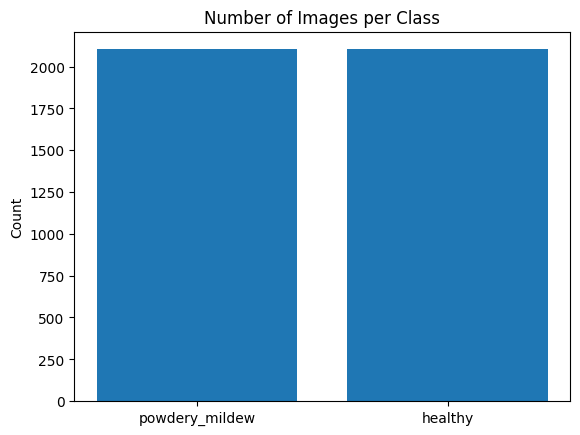

In [4]:
plt.bar(counts.keys(), counts.values())
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

## Class Distribution

The dataset contains images for both healthy and powdery mildew leaves.  
The classes appear balanced, which is beneficial for training a classification model as it reduces bias toward one class.

In [5]:
IMG_SIZE = (100, 100)

In [6]:
def load_images(label):
    images = []
    folder = os.path.join(data_dir, label)
    
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file)).resize(IMG_SIZE)
        img = np.array(img) / 255.0
        images.append(img)
        
    return np.array(images)

In [7]:
healthy_images = load_images("healthy")
mildew_images = load_images("powdery_mildew")

In [9]:
avg_healthy = np.mean(healthy_images, axis=0)
avg_mildew = np.mean(mildew_images, axis=0)

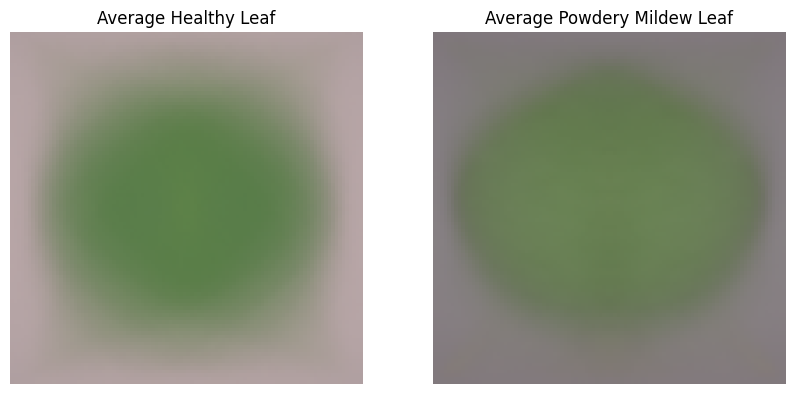

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(avg_healthy)
ax[0].set_title("Average Healthy Leaf")
ax[0].axis("off")

ax[1].imshow(avg_mildew)
ax[1].set_title("Average Powdery Mildew Leaf")
ax[1].axis("off")

plt.show()

## Average Images Insight

The average images highlight general colour and texture differences.  
Powdery mildew leaves show lighter and patchier regions compared to the more uniform green appearance of healthy leaves.

In [11]:
var_healthy = np.std(healthy_images, axis=0)
var_mildew = np.std(mildew_images, axis=0)

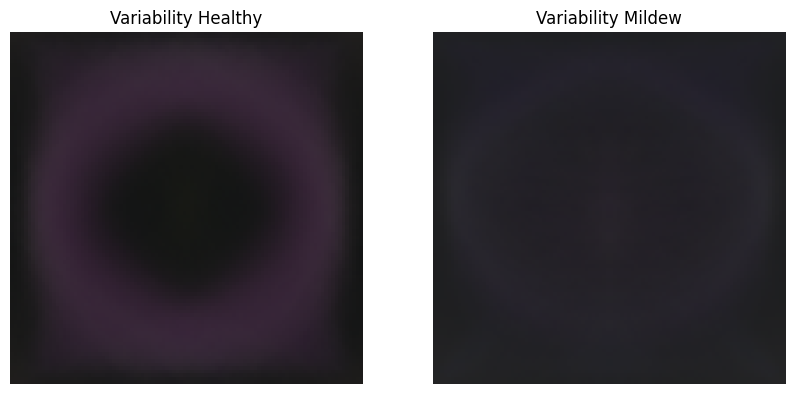

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(var_healthy)
ax[0].set_title("Variability Healthy")
ax[0].axis("off")

ax[1].imshow(var_mildew)
ax[1].set_title("Variability Mildew")
ax[1].axis("off")

plt.show()

## Variability Insight

The variability images show how much pixel values differ across images.  
Higher variability in mildew images suggests irregular patterns caused by infection.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


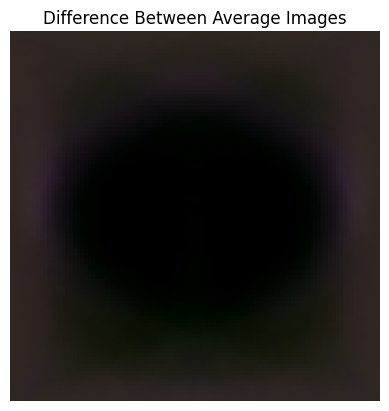

In [13]:
diff = avg_healthy - avg_mildew

plt.imshow(diff)
plt.title("Difference Between Average Images")
plt.axis("off")
plt.show()

## Difference Insight

The difference image highlights the areas where healthy and mildew leaves diverge.  
This confirms that there are detectable visual features that can be used for classification.

In [14]:
def montage(images, title):
    fig, axes = plt.subplots(3, 3, figsize=(6,6))
    fig.suptitle(title)
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.axis("off")
        
    plt.show()

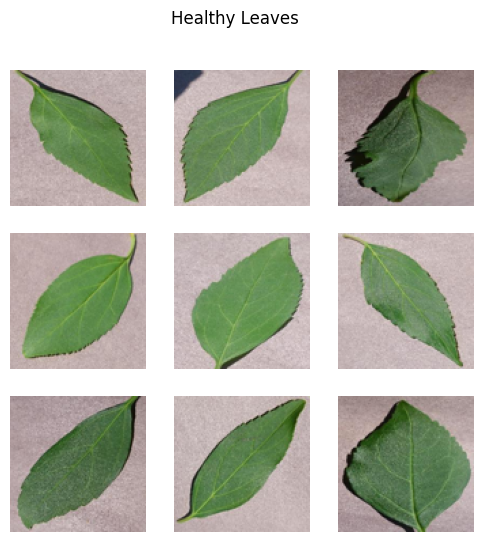

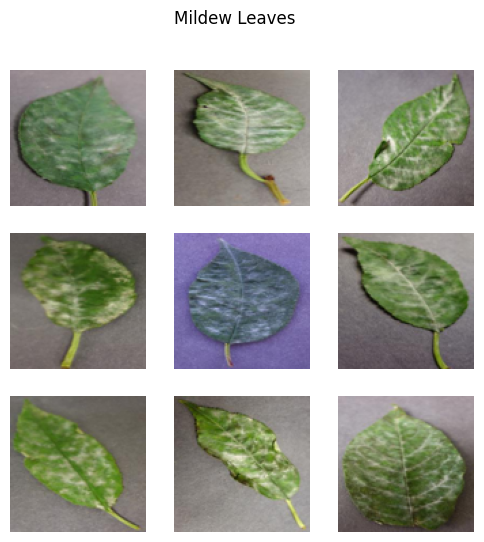

In [15]:
montage(healthy_images, "Healthy Leaves")
montage(mildew_images, "Mildew Leaves")

## Montage Insight

The montage shows individual examples of each class.  
Powdery mildew leaves display visible white fungal patterns, while healthy leaves are consistently green.

## Conclusions

The analysis demonstrates clear visual differences between healthy and powdery mildew leaves.  
These differences include variations in colour, texture, and visible fungal patterns.

This supports the business requirement to visually differentiate leaf conditions and confirms that a machine learning model can learn these patterns for classification.